# Fysikkprosjekt

## Oppgave 1

### 1a

Vi har

$$
\frac{d^2 y}{dx^2} = -4\sin(2x),\qquad y(0)=0,\qquad y'(0)=2.
$$

ved å ta integralet

$$
\frac{dy}{dx} = \int -4\sin(2x) \;dx = 2\cos(2x) + c
$$

setter vi inn for $y'(0)=2$

$$
2\cos(0) + c = 2  \qquad \Leftrightarrow \qquad c = 0
$$

Så integrerer vi en gang til

$$
y = \int 2\cos(2x) \; dx = \sin(2x) + c
$$

hvor vi setter inn $y(0) = 0$

$$
\sin(0) + c = 0  \qquad \Leftrightarrow \qquad c = 0
$$

altså er løsningen til $\frac{d^2 y}{dx^2}$

$$
y = \sin(2x)
$$

### 1b

Putter svarene fra 1a i en vektor
$$
\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x) \end{pmatrix} =
\begin{pmatrix} \sin(2x) \\ 2\cos(2x) \end{pmatrix} \qquad ,\qquad 
\vec{y}(0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}
$$

### 1c

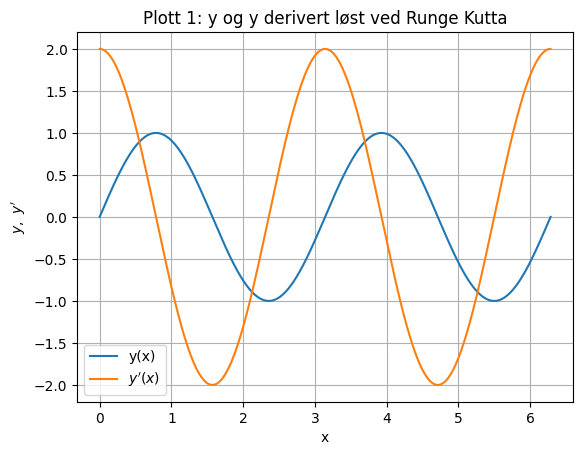

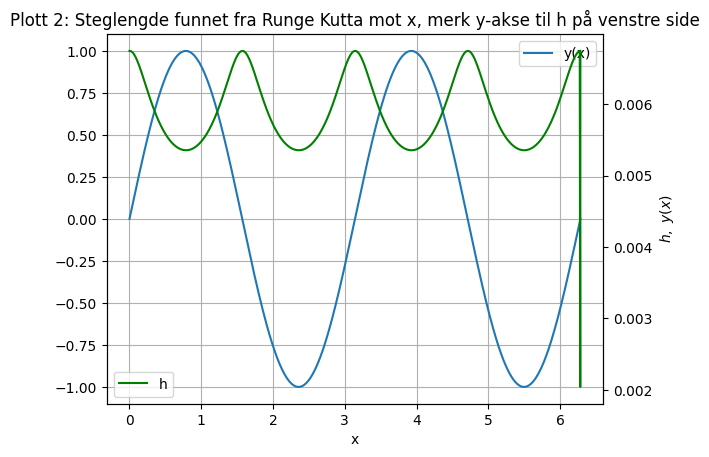

1071 1072


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import time

#Runge-Kutta metode
def RK(x_init,x_end,y_init,h0,tol,f,alpha):
    #Definerer variabler i lister
    h = [h0] #Steglengde mellom hvert steg, x_(n) - x_(n-1)
    h_with_discarded = [h0]   #Alle steglengder blir lagt til i listen, uavhengig om de er innenfor toleransen satt
    x = [x_init]   
    y_1 = [y_init[0]]   # y, svaret på likningen gitt 
    y_2 = [y_init[1]]   # y'
    n = 0   #Antall steg tatt
    
    #Selve metode for å regne Runge-Kutta
    k_1 = f(x[n], np.array([y_1[n], y_2[n]]))
    while x_end - x[n] > 0:
        y_cur = np.array([y_1[n], y_2[n]])
        h[n] = min(h[n],x_end - x[n])
    
        
        k_2 = f(x[n] + 1/2*h[n], y_cur + 1/2*h[n]*k_1)
        k_3 = f(x[n] + 3/4*h[n], y_cur + 3/4*h[n]*k_2)
        y_new = y_cur + 1/9*h[n]*(2*k_1 + 3*k_2 + 4*k_3)

        k_4 = f(x[n]+h[n],y_new)
        z_new = y_cur + 1/24*h[n]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)
        
        est = np.sqrt(np.sum((y_new - z_new)**2))

        h_new = alpha*h[n]*(tol/est)**(1/3)
        h_with_discarded.append(h_new)

        if est < tol:
            x.append(x[n] + h[n])
            y_1.append(y_new[0])
            y_2.append(y_new[1])
            n = n + 1
            k_1 = k_4
            h.append(h_new)
        else:
            h[n] = h_new
    return x, y_1,y_2, h, h_with_discarded

#funsjon som brukes i oppgave 1c-1f
def f(x,y):
    return np.array([y[1],-4*np.sin(2*x)])

        
def oppg_c():
    #oppgitte verdier
    x_init = 0
    x_end = 2*np.pi
    alpha = 0.8  #"Pessimistfaktor" for h
    tol = 10**-7 #Toleranse
    y_init = np.array([0.,2.]) #y_init er en vektor der y_init[0] = y(altså løsningen)  og y_init[1] = y'
    h0 = 0.01  #Første steglengde


    x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)

    #Plotter y og y' mot x
    plt.plot(x, y_1, label = 'y(x)')
    plt.plot(x, y_2, label = r"$y'(x)$")
    plt.xlabel("x")
    plt.ylabel(r"$y,\ y'$")
    plt.title('Plott 1: y og y derivert løst ved Runge Kutta')
    plt.grid()
    plt.legend()
    plt.show()

    #Plotter h og y mot x, merk to ulike y-akser
    fig, ax1 = plt.subplots()
    ax1.plot(x, y_1, label = 'y(x)')
    plt.grid()
    ax2 = ax1.twinx()
    ax2.plot(x, h, color = 'g', label = 'h')
    ax1.set_xlabel('x')
    plt.ylabel(r"$h,\ y(x)$")
    ax2.legend()
    ax1.legend()
    plt.title('Plott 2: Steglengde funnet fra Runge Kutta mot x, merk y-akse til h på venstre side')
    plt.show()
    print(len(h),len(h_w_disc))

oppg_c()


I plott 1 ser man løsningen til $y''(x)$ funnet med Runge-Kutta-metoden (RK). Disse er ganske lik den analytiske løsningen, mer om det senere.

I plott 2 ser man steglengden h som regnes for hvert steg i RK og y, dette for å vise sammenhengen mellom dem. Som plottet viser er det slik at jo mer lineært y oppfører seg, desto lengre blir steglengden. Motsatt blir h mindre i ekstremalpunktene, da stigningen endres raskere her. Det gir altså mening, og viser hvodan metoden endrer på h for hvert steg for å spare iterasjoner uten å få mer feil. Merk også at det er to y-akser der den til høyre angir h-verdier og den til venstre angir $y(x)$.


### 1d

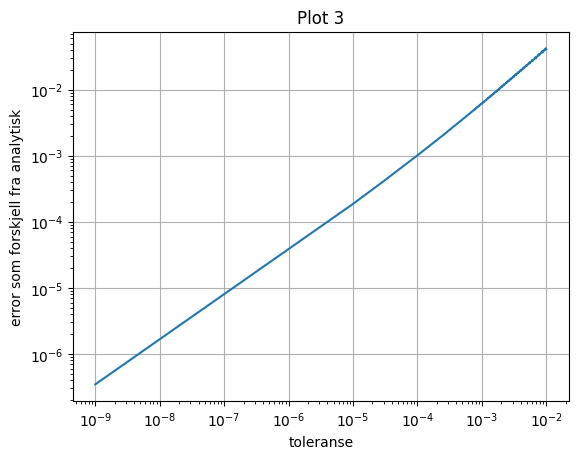

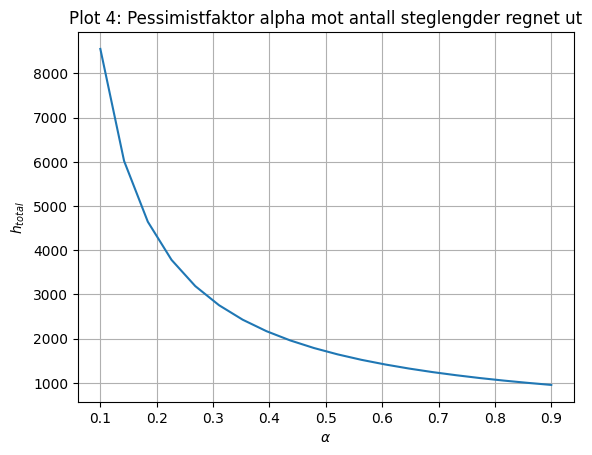

In [3]:
#Den analytiske løsningen til likningen i oppgave 1a
def y_anal(x):
    return np.sin(2*np.array(x))

def oppg_d():
    #Definerer variable
    x_init = 0
    x_end = 2*np.pi
    y_init = np.array([0.,2.])   
    h0 = 0.001   
    alpha = 0.8  

    #Lager en liste med ulike toleranseverdier for å plotte dem mot erroren
    tol_list_len = 1000
    tol_list = np.linspace(10**(-9),10**(-2),tol_list_len)
    error_list =[]

    #Itererer gjennom de ulike toleransene og regner ut erroren 
    for tol in tol_list:
        x, y_1_built, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        error_list.append(np.sum(np.absolute(y_anal(x) - y_1_built)))
        
    #Plotter
    plt.loglog(tol_list, error_list)
    plt.xlabel('toleranse')
    plt.ylabel('error som forskjell fra analytisk')
    plt.title('Plot 3')
    plt.grid()
    plt.show()

    ############################################################################################
    #Definerer variabel, resten er definert fra før
    tol = 10**(-7)

    #Lager en liste med ulike alphaverdier for å plotte mot antall steglengder RK regner ut
    alpha_list_len = 20
    list_alpha = np.linspace(0.1,0.9,alpha_list_len)
    h_tot_w_disc_list = []

    #Itererer gjennom de ulike alphaene og finner alle steglengdene som blir regnet, også forkastede
    for alpha in list_alpha:
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        h_tot_w_disc_list.append(len(h_w_disc))

    #Plotter
    plt.plot(list_alpha,h_tot_w_disc_list)
    plt.ylabel(r'$h_{total}$')
    plt.xlabel(r'$\alpha$')
    plt.title('Plot 4: Pessimistfaktor alpha mot antall steglengder regnet ut')
    plt.grid()
    plt.show()
oppg_d()
  

I plott 3 ser man hvordan en økende toleranse gir en større error. Dette gir mening da en mindre toleranse krever en løsning som er mer riktig, gjennom å utføre et ekstra steg med RK og sammenligne og deretter muligens forkaste svaret.

I plott 4 ser mat at antall utregnede steg minker med økende alpha. Dette gir mening da størrelsen på $\alpha$ er proposjonal med den nye steglengden. Dette ser man i $ h_{new} = \alpha h_n (tol/est)^{1/3}$. $\alpha$ er altså en parameter man lett kan justere på hvis man ønsker større eller mindre steg for alle iterasjoner.

### 1e

In [7]:
#Funksjon bruk i oppgave 1e
def g(z):
    return z + np.sin(z) + np.cos(z)

#Sekantmetoden, returnerer en liste med alle gjettede x i g(x), der x[-1] gir g(x[-1]) = 0
def secant(g, z_0, z_1, tol):
    z = [z_0,z_1]
    n = 1
    while np.absolute(z[n-1] - z[n]) >= tol:
        z.append((z[n-1]*g(z[n]) - z[n]*g(z[n-1]))/(g(z[n]) - g(z[n-1])))
        n = n + 1
    return z


def oppg_e():
    #Finner roten til g med sekantmetoden
    z = secant(g,12,10,10**(-7))
    print(f'Roten av g er ved z = {z[-1]}')
    
    if g(z[-1]) == 0:
        print('z funnet gir 0')
    elif np.abs(g(z[-1])) < 1e-15:
        print(f'g(z) = {g(z[-1])}, som ikke akkurat 0, men den er ekstremt nært')

oppg_e()


Roten av g er ved z = -0.4566247045676308
g(z) = -1.1102230246251565e-16, som ikke akkurat 0, men den er ekstremt nært


Metoden gir ikke akkurat 0, men den gir en verdi nær nok. Det skjekkes ved å putte inn funnet z i g.

### 1f

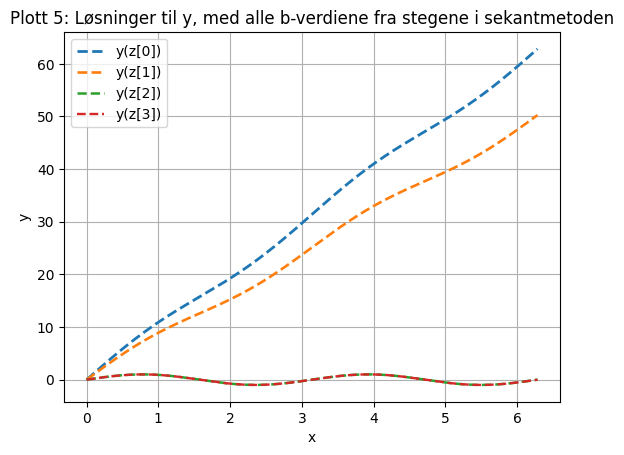

In [8]:
#Boundry value problem solver
def BVP(x_init, x_end, y_init_BVP, f):
    #Her er y_init_BVP et array med to elementer med verdien til randbetingelsene,
    #i denne oppgaven er de begge 0
    #Definerer variable som holdes konstant i denne oppgaven
    b_0 = 12
    b_1 = 10
    tol = 10**(-7)
    alpha = 0.8
    h0 = 0.001
    
    
    #Definerer en funksjon som gir y-verdien på x_end, der b = y'
    def y_at_end(b):
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, np.array([y_init_BVP[0],b]), h0, tol, f, alpha)
        return y_1[-1] - y_init_BVP[1]
    b_cor = secant(y_at_end, b_0, b_1, tol) #Gir den korrekte b-verdien i b_cor[-1]
    x_list = []
    y_list = []


    #itererer gjennom de ulike b-ene som ble funnet med sekantmetoden og legger verdiene i liste
    for b in b_cor:
        y_init = np.array([0.,b])
        x, y_1, y_2, h, h_w_disc = RK(x_init, x_end, y_init, h0, tol, f, alpha)
        x_list.append(x)
        y_list.append(y_1)

    #returnerer listene med listene med lister av x- og y-verdier og listen med b-verdier
    return  x_list, y_list, b_cor

def oppg_f():
    #Bruker BVP til å løse 1a
    x_list, y_list, b = BVP(0,2*np.pi, np.array([0,0]),f)
    
    #Plotter alle løsningene med ulik b-verdi funnet med sekantmetoden
    for x in range(len(b)):
        plt.plot(x_list[x],y_list[x], linewidth = 2 - x/10, linestyle = '--', label = f'y(z[{x}])')
    
    #Plotter
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 5: Løsninger til y'', med alle b-verdiene fra stegene i sekantmetoden')
    plt.grid()
    plt.legend()
    plt.show()

oppg_f()


Plott 5 viser de ulike løsningene y hvor alle stegene i sekantmetoden plottes, ikke bare løsningen til sekantmetoden. z[0] og z[1] er gjett vi har valgt selv, også finner sekantmetoden z[3] og z[4]. Plottet viser at den er svært effektiv (det er nesten suspekt), da den regner ut z[4] og ser at den er ekstremt nært z[3] og returnerer z. Den klarer altså å finne den riktige roten på praktisk talt bare en iterasjon.

### 1g

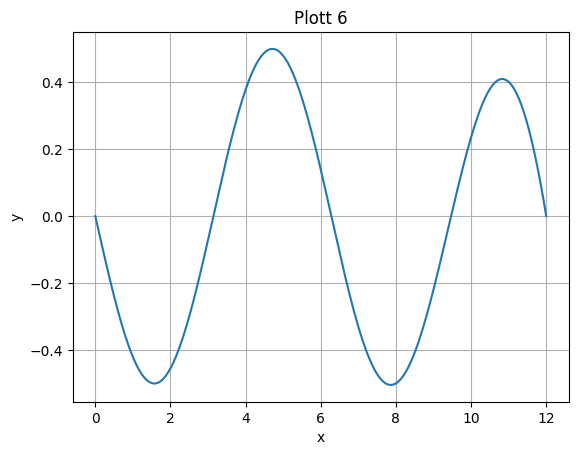

In [9]:
#Funksjon som brukes i 1g og 1h
def F(x,y):
    return np.array([y[1],y[0] + np.sin(x)])

def oppg_g():
    #Bruker den selvlagde løseren
    y = np.array([0,0])
    x_list, y_list, z = BVP(0,12, y, F)

    #Plotter
    plt.plot(x_list[-1],y_list[-1], label = 'BVP')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 6')
    plt.grid()
    plt.show()

oppg_g()

Plott 6 er løsningen på gitte funksjon F med løseren vi har laget selv. I neste oppgave får vi sammenlignet med scipys løsning for å vise om dette faktisk stemmer.

### 1h

Tid brukt på vår randverdiproblemløser(RVPL): 4.129166800001258 
Tid brukt på scipy sin randverdiproblemløser: 0.0019371999987924937


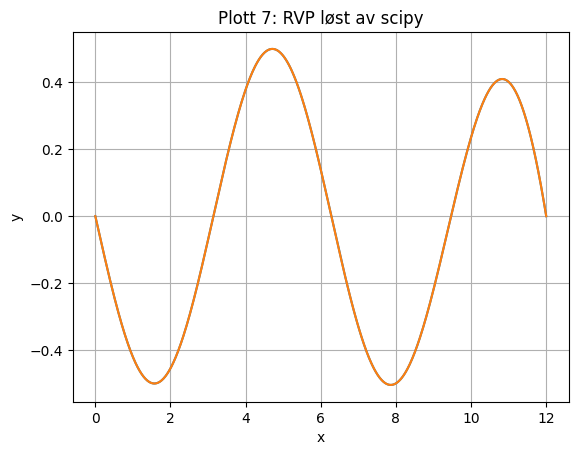

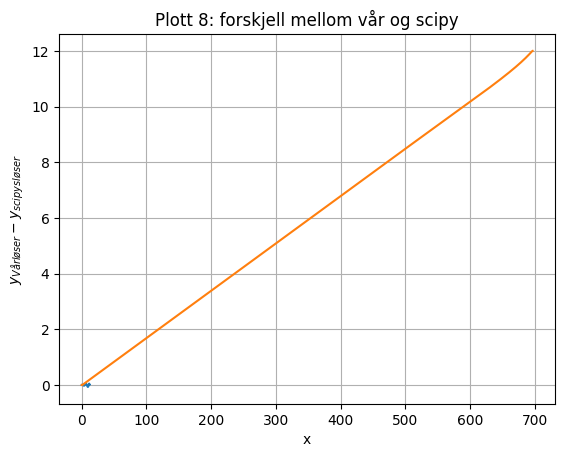

In [13]:

def oppg_h():
    #Initialverdien oppgitt
    y_init_BVP = np.array([0,0])

    #For å løse likningen med scipy
    def bc(ya, yb):
        return np.array([ya[0] - y_init_BVP[0], yb[0] - y_init_BVP[1]]) 

    #Tar tiden til vår løser
    t_own_start = time.perf_counter()
    x_list, y_list, z = BVP(0,12, y_init_BVP, F)
    t_own_end = time.perf_counter()
    t_own = t_own_end - t_own_start
    
    #Lager verdier til scipy fra vår liste for å ha samme antall verdier, lettere med plotting
    x = np.linspace(0,12,len(y_list[-1]))
    y_a = np.zeros((2, x.size))

    #Tar tiden scipy bruker for å løse
    t_sci_start = time.perf_counter()
    res = solve_bvp(F, bc, x, y_a)
    t_sci_end = time.perf_counter()
    t_sci = t_sci_end - t_sci_start

    #svaret fra scipy
    y = res['y']

    #Skriver ut hvor lang tid begge tar
    print(f'Tid brukt på vår randverdiproblemløser(RVPL): {t_own} \nTid brukt på scipy sin randverdiproblemløser: {t_sci}')

    #Plotter både vår og scipys løsning
    plt.plot(x_list[-1], y_list[-1])
    plt.plot(x, y[0])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Plott 7: RVP løst av scipy')
    plt.grid()
    plt.show()

    #Plotter forskjellen
    plt.plot(x_list[-1], y_list[-1] - y[0], label = 'feilen mellom scipy og vår RVPL')
    plt.plot(x_list[-1], )
    plt.xlabel('x')
    plt.ylabel(r'$y_{Vår løser} - y_{scipys løser}$')
    plt.title('Plott 8: forskjell mellom vår og scipy')
    plt.grid()
    plt.show()

oppg_h()





I plott 7 ser man løsningen til scipy, og for å vise hvor nær vår løser var er, er i tillegg den også plottet, men plottet ble bak scipys. 

Videre er plott 8 forskjellen mellom vår løser og scipys løser. Det er nok scipys løsning som er nærmere den sanne verdien enn vår, men interessant er at feilen ser ut til å begynne å oscillere fortere. Dette skyldes nok at feilen i hvert steg er ulike for begge, og disse vil da propagere ulikt. I tillegg er scipys løser betraktelig mye raskere, og ikke bare litt, men med en størrelsesorden på 3 i forskjell. Det er altså ikke et spørsmål om hvilke som er bedre å bruke.

# Oppg 2

In [ ]:
import scipy as sp
from functools import partial
from tqdm import tqdm
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True) # Gir oss muligheten til å bruke complex128 og float64
import matplotlib.pyplot as plt

## 2a)

In [ ]:
@jax.jit
def C2x2MatrixToR8Vector(matrix):
    real = jnp.real(matrix)
    imag = jnp.imag(matrix)

    return jnp.concat([real, imag]).flatten()

@jax.jit
def R8VectorToC2x2Matrix(vec):
    matrix = jnp.reshape(vec, (2,2,2))
    matrix = matrix[0] + 1j*matrix[1]

    return matrix


#Testing
test_matrices = list()
for i in range(4):
    key_real = jax.random.key(45+i)
    key_imaginary = jax.random.key(60+i)
    real_part = jax.random.randint(key_real, shape=(2,2), minval=0, maxval=20)
    imaginary_part = 1j*jax.random.randint(key_imaginary, shape=(2,2), minval=0, maxval=20)
    final_matrix = real_part + imaginary_part
    test_matrices.append(final_matrix)


def check_if_equal(m1, m2):
    if jnp.all(m1 == m2):
        return True
    else:
        return False

R8vectors = [C2x2MatrixToR8Vector(v) for v in test_matrices]
for vector, original_matrix in zip(R8vectors, test_matrices):
    print(f"Form på vektor: {vector.shape}")
    has_correct_form = jnp.all(vector[:4].reshape(2,2) == jnp.real(original_matrix)) and jnp.all(vector[4:].reshape(2,2) == jnp.imag(original_matrix))
    print(f"Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: {has_correct_form}\n")


C2x2Matrices = [R8VectorToC2x2Matrix(v) for v in R8vectors]
identical = True
for (transformed_matrix, original_matrix) in zip(test_matrices, C2x2Matrices):
    is_equal = check_if_equal(transformed_matrix, original_matrix)
    if not is_equal:
        identical = False
        break

if not identical:
    print("Funksjonene fungerer ikke som de skal")
else:
    print("Alle matrisene er identiske etter transformasjon tilbake")
    


Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Alle matrisene er identiske etter transformasjon tilbake


Funksjonene virker som de skal. Vi satte opp et par matriser i $\mathbb{C}^{2x2}$ med unike elementer og satte dem som argumenter til $f : \mathbb{C}^{2x2} \rightarrow \mathbb{R}^8$ og verifiserte at det som kom ut var på formen $\left[ a_1 ,a_2,a_3,a_4,b_1,b_2,b_3,b_4\right]$. Deretter transformerte vi tilbake og sammenlignet resultatet med de originale matrisene.

## 2b)

In [ ]:
@jax.jit
def MergeVectors(m1, m2, m3, m4):
    tmp_arr = jnp.concat([m1,m2,m3,m4])
    return tmp_arr.flatten()

@jax.jit
def SplitVectors(m1):
    return m1.reshape(4, 8)


#Testing
test_vectors = list()
for i in range(4):
    key = jax.random.key(45+i)
    vector = jax.random.randint(key_real, shape=(8,), minval=0, maxval=20)
    test_vectors.append(vector)

transformed_vectors = SplitVectors(MergeVectors(test_vectors[0], test_vectors[1], test_vectors[2], test_vectors[3]))

is_identical = jnp.all(jnp.array(test_vectors) == transformed_vectors)

if is_identical:
    print("Vektorene er identisk etter å ha blitt transformert og invers-transformert")
else:
    print("Funksjonene virker ikke som de skal")

Vektorene er identisk etter å ha blitt transformert og invers-transformert


Her laget vi fire vektorer med form (8,) og brukte MergeVectors og deretter SplitVectors på resultatene. Deretter sjekket vi om dette objektet var identisk med det vi startet med, noe den var.

## 2c)

In [ ]:
@jax.jit
def convert_matrices_to_vector(m1, m2, m3, m4):
    matrix_list = [m1, m2, m3, m4]
    real_vectors = [C2x2MatrixToR8Vector(m) for m in matrix_list]
    v = MergeVectors(real_vectors[0], real_vectors[1], real_vectors[2], real_vectors[3])
    return v

@jax.jit
def convert_vector_to_matrices(v):
    real_vectors = SplitVectors(v)
    m1, m2, m3, m4 = [R8VectorToC2x2Matrix(x) for x in real_vectors]
    return m1, m2, m3, m4

test_matrices = list()
for i in range(4):
    key_real = jax.random.key(45+i)
    key_imaginary = jax.random.key(60+i)
    real_part = jax.random.randint(key_real, shape=(2,2), minval=0, maxval=20)
    imaginary_part = 1j*jax.random.randint(key_imaginary, shape=(2,2), minval=0, maxval=20)
    final_matrix = real_part + imaginary_part
    test_matrices.append(final_matrix)

vector = convert_matrices_to_vector(test_matrices[0], test_matrices[1], test_matrices[2], test_matrices[3])
print("Matriser:\n")
print(test_matrices[0], '\n\n', test_matrices[1], '\n\n', test_matrices[2], '\n\n', test_matrices[3], '\n\n')
print("Vektor:")
print(vector)

Matriser:

[[ 9.+12.j 11. +4.j]
 [ 8.+19.j 19. +3.j]] 

 [[9. +5.j 5.+10.j]
 [7. +5.j 4. +2.j]] 

 [[7. +9.j 4.+19.j]
 [6.+15.j 1. +0.j]] 

 [[ 1.+18.j 13.+19.j]
 [ 6. +2.j 14. +6.j]] 


Vektor:
[ 9. 11.  8. 19. 12.  4. 19.  3.  9.  5.  7.  4.  5. 10.  5.  2.  7.  4.
  6.  1.  9. 19. 15.  0.  1. 13.  6. 14. 18. 19.  2.  6.]


Som outputen ovenfor viser er vektoren satt opp slik at 8 etterfølgende komponenter (fra start) representerer en av de originale komplekse matrisene, med formatet som vist i 2a)

## 2d)

In [ ]:
@jax.jit
def calc_N(gamma, gamma_tilde):
    N = jnp.linalg.inv(jnp.identity(2) - jnp.einsum('ij, jk', gamma, gamma_tilde))
    return N

@jax.jit
def calc_N_tilde(gamma, gamma_tilde):
    N_tilde = jnp.linalg.inv(jnp.identity(2) - jnp.einsum('ij, jk', gamma_tilde, gamma))
    return N_tilde

@jax.jit
def calc_dv(v, eps, delta):
    'Derivert av v-vektoren (32x1)'
    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(v)

    gamma_derivative = omega
    gamma_tilde_derivative = omega_tilde

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    omega_derivative = -2j * (eps + 1j*delta) * gamma - 2* jnp.einsum('ij,jk,kl,lm', omega, N_tilde, gamma_tilde, omega)
    omega_tilde_derivative = -2j * (eps + 1j*delta) * gamma_tilde - 2* jnp.einsum('ij,jk,kl,lm', omega_tilde, N, gamma, omega_tilde)

    dv = convert_matrices_to_vector(gamma_derivative, gamma_tilde_derivative, omega_derivative, omega_tilde_derivative)
    return dv

## 2e)

In [ ]:
@jax.jit
def calc_dvec(x: jnp.array, vec : jnp.array, eps, delta):
    'Derivert av matrise av v-vektorer'
    dvec = jax.vmap(calc_dv, in_axes=(1, None, None), out_axes=1)(vec, eps, delta)
    return dvec

## 2f)

In [ ]:
@jax.jit
def calc_boundary_normmetals(v_left,v_right, zeta, l):
    'Beregning av grensebetingelser for system av kun normale metaler, dvs alle ricatti-matriser i grenser er null'
    gamma_left, gamma_left_tilde, omega_left, omega_left_tilde = convert_vector_to_matrices(v_left)
    gamma_right, gamma_right_tilde, omega_right, omega_right_tilde = convert_vector_to_matrices(v_right)

    N_left = calc_N(gamma_left, gamma_left_tilde)
    N_left_tilde = calc_N_tilde(gamma_left, gamma_left_tilde)

    N_right = calc_N(gamma_right, gamma_right_tilde)
    N_right_tilde = calc_N_tilde(gamma_right, gamma_right_tilde)

    eq13 = omega_right + jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_right, -gamma_right)
    eq14 = omega_right_tilde + jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_right_tilde, -gamma_right_tilde)

    eq15 = omega_left - jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_left, -gamma_left)
    eq16 = omega_left_tilde - jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_left_tilde, -gamma_left_tilde)

    final_v = convert_matrices_to_vector(eq13, eq14, eq15, eq16)
    return final_v

## 2g) 

In [ ]:
def oppgave_2g():
    epsilon = jnp.array([2,1,0])
    lengths = l = 1
    delta = 0.01
    zeta = 3
    xm = 101

    y_all_energies = list()
    y = jnp.zeros((32,xm))
    x = jnp.linspace(0,l,xm)
    for eps in tqdm(epsilon):
        
        #Bruker partial for å fryse parameterverdier (epsilon, delta osv.) for å kunne bruke funksjonen i solve_bvp
        partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
        partial_boundary = partial(calc_boundary_normmetals, zeta=zeta, l=l)
        sol = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm)
        y = sol['y']
        y_all_energies.append(y)

    return x, jnp.array(y_all_energies)


x, y_all_energies = oppgave_2g()
sum_solution_not_zero = (~jnp.isclose(y_all_energies, 0)).sum() # Teller antall verdier der løsning IKKE er 0
print(f"Antall punkter der løsning ikke er null: {sum_solution_not_zero}")


100%|██████████| 3/3 [00:01<00:00,  2.74it/s]

Antall punkter der løsning ikke er null: 0


Vi løser systemet med begge grenseverdiene lik null og med begge gjetningene lik null. Dermed vil den deriverte i alle likningene 9-12 ende med å være lik null. Dette gjelder også for likning 13-16. Derfor forventer vi at alle løsningsvektorene blir null, og dermed at tilstandstettheten vil bli konstant. Dette stemmer; *solve_bvp* returnerer alle løsningsvektorer lik $\vec{0}$. Dette gir mening ettersom vi essensielt ser på tre vanlige metaller plassert ved siden av hverandre, noe som betyr at det ikke er noen superledere tilstede som har mulighet for å "lekke inn" i det normale metallet.

## 2h)

100%|██████████| 3/3 [00:00<00:00, 20.79it/s]


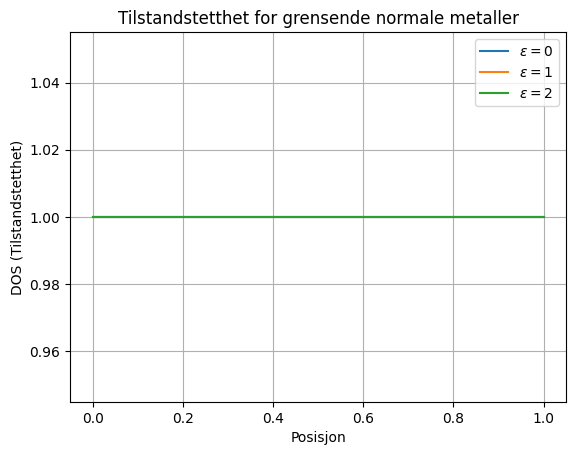

In [ ]:
@jax.jit
def CalculateGreensFunction(solution):

    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(solution)

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    topLeft = 2*N - jnp.identity(2)
    topRight = 2*N @ gamma
    bottomLeft = -2*N_tilde @ gamma_tilde
    bottomRight = -2*N_tilde + jnp.identity(2)

    greens = jnp.block([[topLeft, topRight], [bottomLeft, bottomRight]])
    return greens

@jax.jit
def CalculateDensityOfState(greensFunction): 
    roHat3 = jnp.array(((1,0,0,0),(0,1,0,0),(0,0,-1,0),(0,0,0,-1)))
    density = jnp.real(jnp.einsum("ii",roHat3 @ greensFunction)) / 4
    density = density.reshape(-1, 1)
    return density

def oppgave_2h():
    
    x, y_all_energies = oppgave_2g()
    for idx, y in enumerate(y_all_energies):
        greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(y)
        density = jax.vmap(CalculateDensityOfState)(greensFunctions).flatten()
        plt.plot(x, density, label=f"$\\varepsilon = {idx}$")
    
    plt.grid()
    plt.legend()
    plt.xlabel("Posisjon")
    plt.ylabel("DOS (Tilstandstetthet)")
    plt.title("Tilstandstetthet for grensende normale metaller")
    plt.show()

oppgave_2h()

## 2i)

In [ ]:
@jax.jit
def nuPluss(eps, delta):
    return jnp.arctanh(1/(eps + delta*1j))

@jax.jit
def nuMinus(eps, delta):
    return jnp.arctanh(-1/(eps + delta*1j))

@jax.jit
def fetch_nonzero_riccati(eps, delta, phaseL = 0, phaseR = 0):
    plussElement = jnp.sinh(nuPluss(eps, delta))/(1+jnp.cosh(nuPluss(eps, delta)))
    minusElement = jnp.sinh(nuMinus(eps, delta))/(1+jnp.cosh(nuMinus(eps, delta)))

    material_gamma_left = jnp.array(((0, plussElement),(minusElement, 0)))*jnp.exp(phaseL*1j)
    material_gamma_tilde_left = jnp.array(((0, minusElement),(plussElement, 0)))*jnp.exp(-phaseL*1j)

    material_gamma_right = jnp.array(((0, plussElement),(minusElement, 0)))*jnp.exp(phaseR*1j)
    material_gamma_tilde_right = jnp.array(((0, minusElement),(plussElement, 0)))*jnp.exp(-phaseR*1j)
    
    return material_gamma_left, material_gamma_tilde_left, material_gamma_right, material_gamma_tilde_right

@jax.jit
def calc_boundary_superconduct_metals(v_left,v_right, eps, delta, zeta, l, phiL, phiR):
    'Beregning av grensebetingelser for ikke-null riccati-matriser'
    gamma_left, gamma_left_tilde, omega_left, omega_left_tilde = convert_vector_to_matrices(v_left)
    gamma_right, gamma_right_tilde, omega_right, omega_right_tilde = convert_vector_to_matrices(v_right)

    material_gamma_left, material_gamma_left_tilde, material_gamma_right, material_gamma_right_tilde = fetch_nonzero_riccati(eps, delta, phiL, phiR)

    N_left = calc_N(material_gamma_left, material_gamma_left_tilde)
    N_left_tilde = calc_N_tilde(material_gamma_left, material_gamma_left_tilde)

    N_right = calc_N(material_gamma_right, material_gamma_right_tilde)
    N_right_tilde = calc_N_tilde(material_gamma_right, material_gamma_right_tilde)

    eq13 = omega_left + jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_left @ material_gamma_left_tilde), N_left, material_gamma_left -gamma_left)
    eq14 = omega_left_tilde + jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_left_tilde @ material_gamma_left), N_left_tilde, material_gamma_left_tilde -gamma_left_tilde)

    eq15 = omega_right - jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_right @ material_gamma_right_tilde), N_right, material_gamma_right -gamma_right)
    eq16 = omega_right_tilde - jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_right_tilde @ material_gamma_right), N_right_tilde, material_gamma_right_tilde -gamma_right_tilde)

    final_v = convert_matrices_to_vector(eq13, eq14, eq15, eq16)
    return final_v




## 2j)

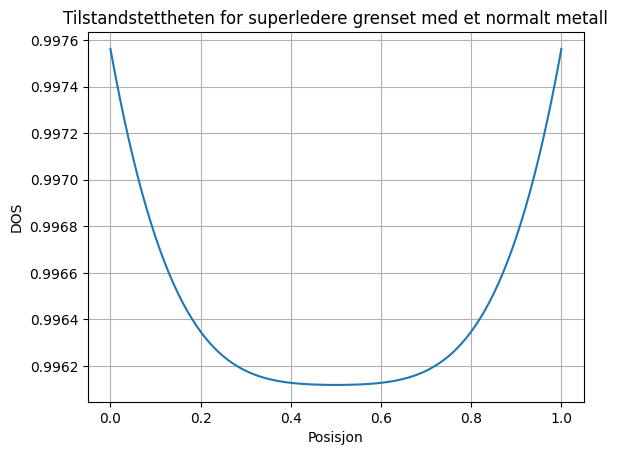

In [ ]:
def oppgave_2j():
    eps = 2
    l = 1
    delta = 0.01
    zeta = 3
    m = 101
    x = jnp.linspace(0, l, m)
    y = jnp.zeros((32,m))
    phiL = phiR = 0

    partial_dvec     =  partial(calc_dvec, eps=eps, delta=delta)
    partial_boundary =  partial(calc_boundary_superconduct_metals, 
                                eps=eps, delta=delta, zeta=zeta, l=l,
                                phiL=phiL, phiR=phiR)


    sol = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y)
    greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(sol["y"])
    density = jax.vmap(CalculateDensityOfState)(greensFunctions).squeeze(axis=-1)
    plt.plot(x, density)
    plt.grid()
    plt.xlabel("Posisjon")
    plt.ylabel("DOS")
    plt.title("Tilstandstettheten for superledere grenset med et normalt metall")
    plt.show()

oppgave_2j()

I figur 1 ser vi at tilstandstettheten for $E - E_F = 2 |\Delta| \iff \varepsilon = 2$ er noe større enn 1. Dermed er det flere tilgjengelige tilstander for disse elektronene i superledende fase enn i normal fase for det superledende materiale. På grunn av The Proximity Effect ("nærhetseffekten") vil denne økningen i antall tilstander "lekke" inn i det normale metallet. Dette gjør at kantene på metallet i normal fase vil ha høyere tilstandstetthet enn ved sentrum i $x = \frac{l}{2}$. Dermed er det å forvente at resultatene vil være likere de i oppgave h, med tilnærmet kontant verdi. 

Når vi plotter dette ser vi at tilstandstettheten er noe lavere i det normale metallet når det grenser til superledere enn når det ikke gjør det. Den forutsatte formen på den plottede kurven stemmer, men ved vår forståelse burde punktene $x \in \{ 0, l\}$ ha tilstandstetthet noe større enn 1 gitt tilstanden i superlederene ved denne energien.


## 2k)

100%|██████████| 101/101 [00:05<00:00, 19.91it/s]


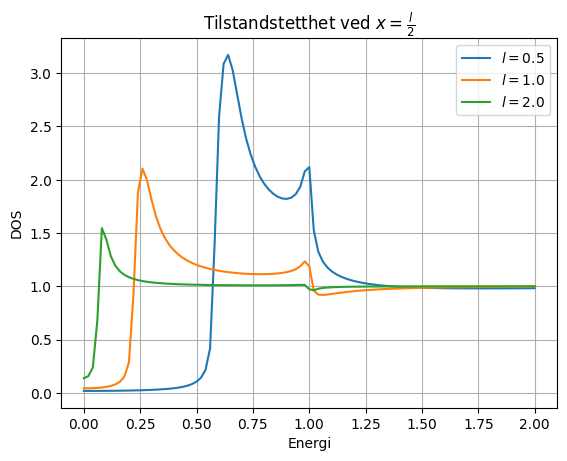

In [ ]:
def oppgave_2k():

    epsilon = jnp.linspace(2,0,101)
    lengths = jnp.array((0.5,1,2))
    delta = 0.01
    zeta = 3
    phiL = phiR = 0
    xm = 101

    y = jnp.zeros((32,xm))
    for l in lengths:
        greensFunctions = list()
        x = jnp.linspace(0,l,xm)
        for eps in tqdm(epsilon):
            partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
            partial_boundary = partial(calc_boundary_superconduct_metals, 
                                       eps=eps, delta=delta, zeta=zeta, l=l,
                                       phiL=phiL, phiR=phiR)

            solution = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm)
            y = solution["y"]
            solutionAtX_2 = solution["y"][:, ((xm)//2)]
            greensFunctions.append(CalculateGreensFunction(solutionAtX_2))


        greensFunctions = jnp.array(greensFunctions, dtype=jnp.complex128)
        DOS = jax.vmap(CalculateDensityOfState)(greensFunctions).flatten()
        plt.plot(epsilon, DOS, label = r"$l =$" + str(float(l)))
    
    plt.grid()
    plt.xlabel("Energi")
    plt.ylabel("DOS")
    plt.title(r"Tilstandstetthet ved $x = \frac{l}{2}$")
    plt.legend()
    plt.show()

oppgave_2k()

Det superledende gapet dukker opp for lavere energier. Vi ser også at etterhvert som lengden av den normale fasen øker minker mengden energier som inngår i gapet. Dette skyldes at nærhetseffekten avtar etterhvert som avstanden mellom superlederene øker. Om vi skal gjette tipper vi det skyldes at sannsynligheten for tunnelering synker. 

Videre ser vi at for $\varepsilon > 1$ jevner tilstandstettheten ut og går mot den normale fasen, noe som likner på det vi ser i fig 1. Dette er å forvente ettersom vi når energier som er større enn fermienergien, hvilket lar elektroner nå de lendene båndene. Materialet får da normale ledeevner, hvilket stemmer overens med oppg j.


## 2L)

100%|██████████| 101/101 [00:05<00:00, 18.88it/s]


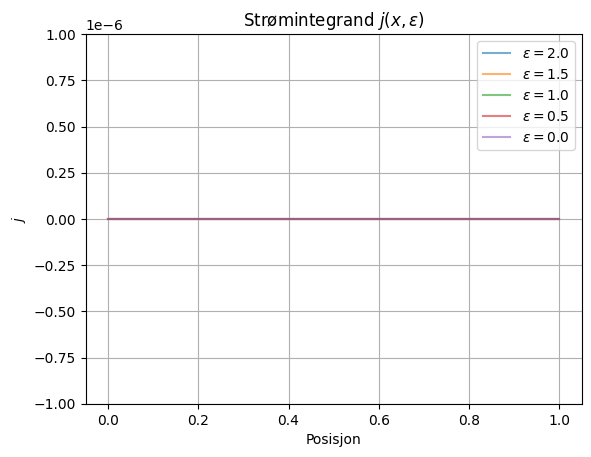

In [ ]:
@jax.jit
def calculate_greens_function_derivative(solution):
    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(solution)

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    N_derivative = jnp.einsum('ij,jk,kl', N, omega @ gamma_tilde + gamma @ omega_tilde, N)
    N_tilde_derivative = jnp.einsum('ij,jk,kl', N_tilde, omega_tilde @ gamma + gamma_tilde @ omega, N_tilde)

    topLeft = N_derivative
    topRight = N @ omega + N_derivative @ gamma
    bottomLeft = -N_tilde @ omega_tilde - N_tilde_derivative @ gamma_tilde
    bottomRight = -N_tilde_derivative

    dgreens = 2 * jnp.block([[topLeft, topRight], [bottomLeft, bottomRight]])
    return dgreens

@jax.jit
def find_current_at_single_point(greensFunction, dgreensFunction):
    roHat3 = jnp.array(((1,0,0,0),(0,1,0,0),(0,0,-1,0),(0,0,0,-1)))
    current = jnp.real(jnp.einsum('ij, ji ->',  roHat3, greensFunction @ dgreensFunction - dgreensFunction @ greensFunction))
    return current

def calculate_currents(lengths, epsilon, phiLeft, phiRight, find_current_for_all_positions=False, show_progress=True):
    epsN = len(epsilon)
    zeta = 3
    delta = 0.01
    l = 1

    currents = []
    xm = epsN
    x = jnp.linspace(0,l,xm)
    y = jnp.zeros((32,xm))

    phiR = phiRight
    for phiL in phiLeft:
        for l in lengths:
            for eps in (tqdm(epsilon) if show_progress else epsilon):
                partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
                partial_boundary = partial(calc_boundary_superconduct_metals, 
                                       eps=eps, delta=delta, zeta=zeta, l=l,
                                       phiL=phiL, phiR=phiR)
                
                
                solution = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm, tol=1E-6)
                y = solution["y"]
                if find_current_for_all_positions:
                    greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(y)
                    dgreensFunctions = jax.vmap(calculate_greens_function_derivative, in_axes=1)(y)
                    currents.append(jax.vmap(find_current_at_single_point, in_axes=(0,0))(greensFunctions, dgreensFunctions))
                    #print(f'All currents has been calculated for eps = {eps :.2f} | Length = {l :.2f} | PhiL = {phiL :.2f}.')
                else:
                    y_singlePoint = solution["y"][:, (xm//2)]  # X = l/2
                    greensFunction = CalculateGreensFunction(y_singlePoint)
                    dgreensFunction = calculate_greens_function_derivative(y_singlePoint)
                    currents.append(find_current_at_single_point(greensFunction, dgreensFunction))
                    #print(f"Current at x=l/2 has been calculated for eps = {eps :.2f} | Length = {l :.2f} | PhiL = {phiL :.2f}")           
                
    return x, jnp.array(currents)


def oppgave_2l():
    epsilon_for_calculation = jnp.linspace(2,0,101)
    epsilon_for_plotting = jnp.array([2, 1.5, 1, 0.5, 0])
    plot_indices = jnp.isin(epsilon_for_calculation, epsilon_for_plotting)
    lengths = [1]
    phiLeft = [0] # Må være liste fordi programmet støtter iterering gjennom flere verdier
    phiRight = 0
    x, current = calculate_currents(lengths, epsilon_for_calculation, phiLeft, phiRight, find_current_for_all_positions=True)
    current_plot_vals = current[plot_indices]
    for (idx, current) in enumerate(current_plot_vals):
        plt.plot(x, current, label=f'$\\varepsilon = {epsilon_for_plotting[idx]}$', alpha=0.6)
    
    plt.grid()
    plt.title("Strømintegrand $j(x,\\varepsilon)$")
    plt.xlabel("Posisjon")
    plt.ylabel("$j$")
    plt.ylim(-1E-6, 1E-6)
    plt.legend()
    plt.show()

oppgave_2l()


Som vist i plottet er strøm-integranden lik null for alle energiene. Dersom man ikke koder inn grenser for y-aksen vil det vise variasjoner på størrelsesordenen $10^{-15}$, men ettersom toleransen på solveren til scipy er satt til $10^{-6}$ er dette et resultat av begrensninger i numerisk beregning og ikke et fysisk resultat.


## 2m)

100%|██████████| 101/101 [00:04<00:00, 21.22it/s]


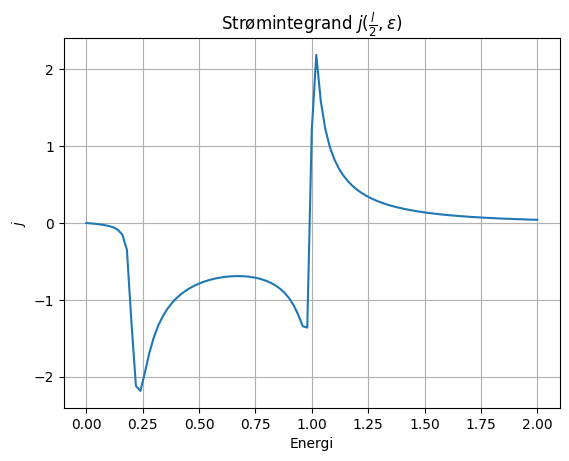

100%|██████████| 101/101 [00:04<00:00, 20.93it/s]


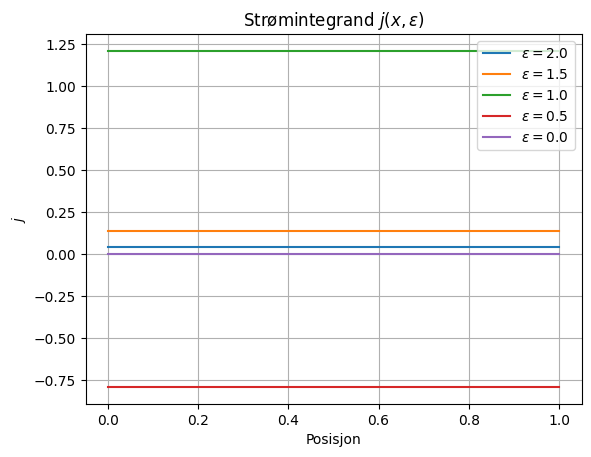

In [ ]:
def oppgave_2m():
    phiLeft = [1]
    phiRight = 0
    epsilon = jnp.linspace(2,0,101)
    epsilon_for_position_plotting = jnp.array([2, 1.5, 1, 0.5, 0])
    plot_indices = jnp.isin(epsilon, epsilon_for_position_plotting)
    lengths = jnp.array([1])

    x, current_plot_vals = calculate_currents(lengths, epsilon, phiLeft, phiRight)
    plt.plot(epsilon, current_plot_vals)
    
    plt.grid()
    plt.title("Strømintegrand $j(\\frac{l}{2}, \\varepsilon)$")
    plt.xlabel("Energi")
    plt.ylabel("$j$")
    plt.show()

    plt.clf() 

    x, current = calculate_currents(lengths, epsilon, phiLeft, phiRight, find_current_for_all_positions=True)
    current_plot_vals = current[plot_indices]
    for (idx, current) in enumerate(current_plot_vals):
        plt.plot(x, current, label=f'$\\varepsilon = {epsilon_for_position_plotting[idx]}$')
    
    plt.grid()
    plt.title("Strømintegrand $j(x,\\varepsilon)$")
    plt.xlabel("Posisjon")
    plt.ylabel("$j$")
    plt.legend()
    plt.show()

oppgave_2m()

Nå som $\Delta\phi\neq0$ får vi som forventet en strøm i metallet, i motsetning til oppgave 2l. Dersom vi istedenfor energi plotter strømmen som funksjon av posisjon for fem utvalgte verdier av epsilon slik som i oppgave 2l ser vi likevel at strømintegranden også her er konservert ettersom den er konstant for alle x, noe som oppfyller bevaringskravet $j(x,\varepsilon) = j(0,\varepsilon)$.

At integranden en konservert gir mening gitt bevaringslovene. Fra energibevaring har vi at dersom et elektron går fra energinivå $\varepsilon_n$ til $\varepsilon_k$ må et annet elektron gjøre det motsatte for at energien skal bevares. Ladnings- og massebevaring tilsier at det ikke spontant kan oppstå nye elektroner. Elektrostatikk tilsier da at dersom elektroner flyter fra et område vil det oppstå en positiv ladning og systemet vil dras mot likevekt. Dermed må integranden være konstant.

## 2n)

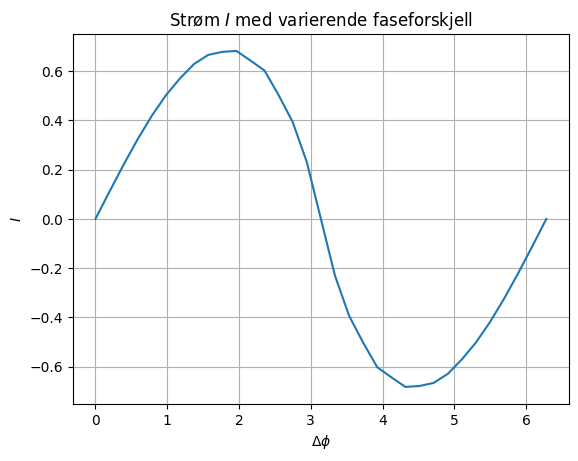

In [ ]:
def integerate_currents(lengths, epsilon, phiLeft, phiRight, show_progress):
    Integrals = []
    x, currents = calculate_currents(lengths, epsilon, phiLeft, phiRight, show_progress=show_progress)
    current_per_phi = currents.reshape(-1, len(epsilon))
    for current in current_per_phi:
        this_integral = sp.integrate.simpson(current, epsilon)
        Integrals.append(this_integral)
    
    return jnp.array(Integrals)

def oppgave_2n():
    phiLeft = jnp.linspace(0, 2*jnp.pi, 33)
    phiRight = 0
    epsilon = jnp.linspace(2,0,101)
    lengths = jnp.array([1])

    Integrals = integerate_currents(lengths, epsilon, phiLeft, phiRight, show_progress=False)
    plt.plot(phiLeft, Integrals)
    plt.xlabel("$\\Delta\\phi$")
    plt.ylabel("$I$")
    plt.title("Strøm $I$ med varierende faseforskjell")
    plt.grid()
    plt.show()

oppgave_2n()

Vi observerer at strømmen øker for økende $\Delta\phi$ inntil et maksimum ved $\Delta\phi = \frac{\pi}{2}$, og den synker deretter til 0 ved $\Delta\phi=\pi$. Deretter speiles den om y-aksen i intervallet $(\pi, 2\pi)$. Med andre ord kan strømmen tilnærmes med en sinusfunksjon. Strømmen er altså periodisk i $\Delta\phi$ med perioden p = $2\pi$.

Videre observerer vi at den sinusodiale formen til $J(\Delta\phi)$ har noen overtoner. Disse har ikke store utslag og blir kun tydelige når vi har høy oppløsning langs $\Delta \phi$-aksen. Vi vet ikke om dette er resultat av at vi integrerer over et mindre intervall for $\varepsilon$ enn det som anses som standard (ref *a* i oppgaveteksten) eller om dette er et faktisk fysisk fenomen som kan observeres.